In [1]:
from vllm import LLM, SamplingParams
import torch
from PIL import Image
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import base64, mimetypes

In [2]:
root_path = "/home/stefan/ioai-prep/kits/rooms"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Data

In [23]:
test_df = pd.read_csv(f"{root_path}/test.csv")
train_df = pd.read_csv(f"{root_path}/train.csv")

test_df["question"] = test_df["question"].apply(lambda x: x[0].upper() + x[1:] + "?")
test_df["img_path"] = test_df["image_id"].apply(lambda x: f"{root_path}/images/{x}.png")

train_df["question"] = train_df["question"].apply(lambda x: x[0].upper() + x[1:] + "?")
train_df["img_path"] = train_df["image_id"].apply(
    lambda x: f"{root_path}/images/{x}.png"
)

test_df.head()

,sample_id,question,image_id,img_path
0,TEST0000,How many drawers are there?,image1362,/home/stefan/ioai-prep/kits/rooms/images/image...
1,TEST0001,How many televisions are there?,image169,/home/stefan/ioai-prep/kits/rooms/images/image...
2,TEST0002,How many flags are visible?,image1326,/home/stefan/ioai-prep/kits/rooms/images/image...
3,TEST0003,How many drawers are there?,image898,/home/stefan/ioai-prep/kits/rooms/images/image...
4,TEST0004,How many chairs are there?,image632,/home/stefan/ioai-prep/kits/rooms/images/image...


How many drawers are there?


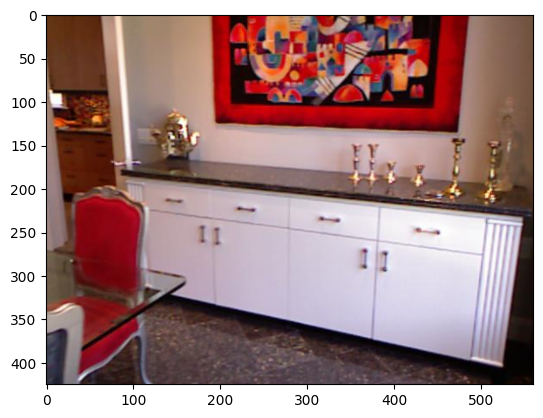

In [4]:
sample_row = test_df.iloc[0]
print(sample_row["question"])
plt.imshow(Image.open(sample_row["img_path"]))

# vLLM inference

In [5]:
llm = LLM(
    model="/mnt/projects/models/Qwen3-VL-8B-Instruct-AWQ-8bit",
    gpu_memory_utilization=0.9,
    max_model_len=1024,
    max_num_seqs=30,
)

INFO 12-10 12:56:15 [utils.py:253] non-default args: {'seed': None, 'max_model_len': 1024, 'max_num_seqs': 30, 'disable_log_stats': True, 'model': '/mnt/projects/models/Qwen3-VL-8B-Instruct-AWQ-8bit'}
WARNING 12-10 12:56:15 [arg_utils.py:1175] `seed=None` is equivalent to `seed=0` in V1 Engine. You will no longer be allowed to pass `None` in v0.13.
INFO 12-10 12:56:15 [model.py:637] Resolved architecture: Qwen3VLForConditionalGeneration
INFO 12-10 12:56:15 [model.py:1750] Using max model len 1024
INFO 12-10 12:56:16 [scheduler.py:228] Chunked prefill is enabled with max_num_batched_tokens=8192.
WARNING 12-10 12:56:17 [system_utils.py:136] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
(EngineCore_DP0 pid=6967) INFO 12-10 12:56:23 [core.py:93] Initializing a V1 LLM engine (v0.12.0) with config: 

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  33% Completed | 1/3 [00:00<00:01,  1.35it/s]
Loading safetensors checkpoint shards:  67% Completed | 2/3 [00:01<00:00,  1.19it/s]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:01<00:00,  1.66it/s]
Loading safetensors checkpoint shards: 100% Completed | 3/3 [00:01<00:00,  1.53it/s]
(EngineCore_DP0 pid=6967) 


(EngineCore_DP0 pid=6967) INFO 12-10 12:56:30 [default_loader.py:308] Loading weights took 2.01 seconds
(EngineCore_DP0 pid=6967) INFO 12-10 12:56:30 [gpu_model_runner.py:3549] Model loading took 10.7507 GiB memory and 2.438456 seconds
(EngineCore_DP0 pid=6967) INFO 12-10 12:56:30 [gpu_model_runner.py:4306] Encoder cache will be initialized with a budget of 151250 tokens, and profiled with 1 video items of the maximum feature size.
(EngineCore_DP0 pid=6967) INFO 12-10 12:56:43 [backends.py:655] Using cache directory: /home/stefan/.cache/vllm/torch_compile_cache/717da617d5/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=6967) INFO 12-10 12:56:43 [backends.py:715] Dynamo bytecode transform time: 10.13 s
(EngineCore_DP0 pid=6967) INFO 12-10 12:56:44 [backends.py:257] Cache the graph for dynamic shape for later use
(EngineCore_DP0 pid=6967) INFO 12-10 12:56:51 [backends.py:288] Compiling a graph for dynamic shape takes 6.64 s
(EngineCore_DP0 pid=6967) INFO 12-10 12:56:53 [mo

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|█| 10/10 [00:00<0
Capturing CUDA graphs (decode, FULL): 100%|██████| 6/6 [00:00<00:00, 26.80it/s]


(EngineCore_DP0 pid=6967) INFO 12-10 12:56:58 [gpu_model_runner.py:4466] Graph capturing finished in 1 secs, took 0.11 GiB
(EngineCore_DP0 pid=6967) INFO 12-10 12:56:58 [core.py:254] init engine (profile, create kv cache, warmup model) took 27.59 seconds
INFO 12-10 12:56:59 [llm.py:343] Supported tasks: ['generate']


In [27]:
sampling_params = SamplingParams(temperature=0.1, top_p=0.95, top_k=0, max_tokens=2)


def file_to_data_url(path: str) -> str:
    mime, _ = mimetypes.guess_type(path)
    with open(path, "rb") as f:
        data = base64.b64encode(f.read()).decode()
    return f"data:{mime or 'image/jpeg'};base64,{data}"

def answer_q(row):
    system_prompt = """You are a precise visual counting assistant.
    Your task: Examine the image carefully and count exactly how many objects 
    match the question. Be very careful and systematic.

    Response format: Answer with ONLY the number, nothing else."""

    conversation = [
        {
            "role": "system",
            "content": system_prompt,
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {"url": file_to_data_url(row["img_path"])},
                },
                {"type": "text", "text": row["question"]},
            ],
        },
    ]

    output = llm.chat(conversation, sampling_params, use_tqdm=False)[0]

    try:
        ans = int(output.outputs[0].text)
    except:
        ans = 0
    return ans

answer_q(sample_row)

4

let's test on the training set

In [28]:
train_answers = []
tdf = train_df.sample(frac=0.1)
for row_idx in tqdm(range(len(tdf))):
    row = tdf.iloc[row_idx]
    train_answers.append(answer_q(row))

100%|██████████| 133/133 [00:15<00:00,  8.80it/s]


In [30]:
mean_absolute_error(tdf["answer"], train_answers)

0.9172932330827067

# Submission

In [32]:
submission = test_df[["sample_id"]]
answers = []

In [33]:
for row_idx in tqdm(range(len(test_df))):
    row = test_df.iloc[row_idx]
    answers.append(answer_q(row))

100%|██████████| 367/367 [00:41<00:00,  8.77it/s]


In [37]:
submission["answer"] = answers

submission["answer"][submission["answer"] == 0] = 2

submission.head()

/tmp/ipykernel_6794/3937284984.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  submission["answer"] = answers
/tmp/ipykernel_6794/3937284984.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a singl

,sample_id,answer
0,TEST0000,4
1,TEST0001,1
2,TEST0002,1
3,TEST0003,6
4,TEST0004,3


<Axes: >

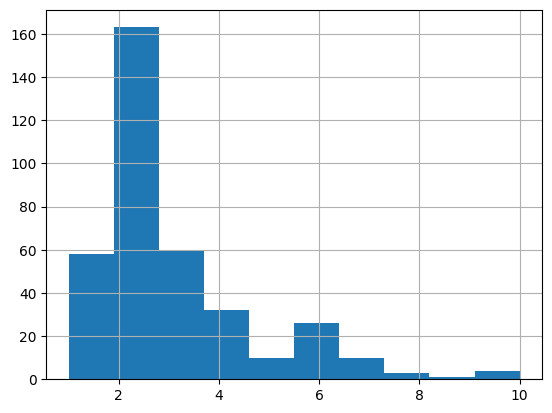

In [38]:
submission["answer"].hist()

In [39]:
submission.to_csv(f"{root_path}/submission.csv")